# Real-world Data Wrangling

In this project, you will apply the skills you acquired in the course to gather and wrangle real-world data with two datasets of your choice.

You will retrieve and extract the data, assess the data programmatically and visually, accross elements of data quality and structure, and implement a cleaning strategy for the data. You will then store the updated data into your selected database/data store, combine the data, and answer a research question with the datasets.

Throughout the process, you are expected to:

1. Explain your decisions towards methods used for gathering, assessing, cleaning, storing, and answering the research question
2. Write code comments so your code is more readable

Before you start, install the some of the required packages. 

In [1]:
!python -m pip install kaggle==1.6.12

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.2/78.2 kB 14.5 MB/s eta 0:00:00
  Created wheel for kaggle: filename=kaggle-1.6.12-py3-none-any.whl size=102969 sha256=447deefa0166f47b6e0e9e5151e31b1cfaf4f17b03fe9d9a0bd8c229f52dcdf8
  Stored in directory: /home/student/.cache/pip/wheels/1e/0b/7c/50f8e89c3d2f82838dbd7afeddffbb9357003009ada98216c7
Successfully built kaggle
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
!pip install --target=/workspace ucimlrepo numpy==1.24.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 83.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 102.6 MB/s eta 0:00:0000:0100:01
  Using cached certifi-2026.2.25-py3-none-any.whl (153 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 40.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 35.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 51.1 MB/s eta 0:00:00


**Note:** Restart the kernel to use updated package(s).

## Real-World Data Wrangling Project

I'll use two related, richly messy datasets:

World Happiness Report (manual download from Kaggle)
World Population by Countries 1960–2021 (programmatic download)

## 1. Gather data

In this section, you will extract data using two different data gathering methods and combine the data. Use at least two different types of data-gathering methods.

In [63]:
# Install/import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

pd.set_option('display.max_columns', None)

### **1.1.** Problem Statement

This project investigates whether national wealth and population trends
are associated with self-reported happiness scores across countries.
I will wrangle the World Happiness Report dataset (2015–2022) and the
World Bank World Population dataset (1960–2021), both of which share a
country identifier that allows meaningful merging.
The research question: Do countries with higher GDP per capita and
stable population growth tend to report higher happiness scores?

Finding the right datasets can be time-consuming. Here we provide you with a list of websites to start with. But we encourage you to explore more websites and find the data that interests you.

* Google Dataset Search https://datasetsearch.research.google.com/
* The U.S. Government’s open data https://data.gov/
* UCI Machine Learning Repository https://archive.ics.uci.edu/ml/index.php


### **1.2.** Gather at least two datasets using two different data gathering methods

List of data gathering methods:

- Download data manually
- Programmatically downloading files
- Gather data by accessing APIs
- Gather and extract data from HTML files using BeautifulSoup
- Extract data from a SQL database

Each dataset must have at least two variables, and have greater than 500 data samples within each dataset.

For each dataset, briefly describe why you picked the dataset and the gathering method (2-3 full sentences), including the names and significance of the variables in the dataset. Show your work (e.g., if using an API to download the data, please include a snippet of your code). 

Load the dataset programmtically into this notebook.

#### Dataset 1 — World Happiness Report (Manual Download)

Type: CSV Files (five yearly files: 2015.csv – 2019.csv)

Method: The data was gathered using the "Manual Download" method from Kaggle
(https://www.kaggle.com/datasets/unsdsn/world-happiness). I chose this dataset
because it provides country-level happiness scores alongside socioeconomic
indicators across multiple years, making it ideal for investigating the
relationship between wealth, health, and wellbeing.

Dataset variables:
- country: Name of the country surveyed
- happiness_score: Self-reported life satisfaction score (scale ~0–10)
- gdp_per_capita: Log GDP per capita — measures national economic output
- life_expectancy: Healthy life expectancy index — measures population health
- year: Survey year (added during loading since original files lack it)

In [64]:
import zipfile
import os

# Unzip the manually uploaded Kaggle archive
ZIP_PATH    = "world-happiness.zip"
DEST_FOLDER = "happiness_data"

os.makedirs(DEST_FOLDER, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(DEST_FOLDER)
    print("Files extracted:")
    for name in sorted(zip_ref.namelist()):
        print(f"  {name}")

print(f"\n✔  All files extracted to '{DEST_FOLDER}/'")

Files extracted:
  2015.csv
  2016.csv
  2017.csv
  2018.csv
  2019.csv

✔  All files extracted to 'happiness_data/'


In [65]:
# DATASET 1: World Happiness Report

# Load each year and standardize column names
def load_happiness_data(folder='happiness_data'):
    """
    Load all yearly World Happiness CSVs from a folder,
    normalize column names, and concatenate into one dataframe.
    """
    # Map of raw column names across years to standardized names
    col_map = {
        'Country': 'country',
        'Country name': 'country',
        'Country or region': 'country',
        'Happiness Score': 'happiness_score',
        'Happiness.Score': 'happiness_score',
        'Score': 'happiness_score',
        'Life Ladder': 'happiness_score',
        'Economy (GDP per Capita)': 'gdp_per_capita',
        'Economy..GDP.per.Capita.': 'gdp_per_capita',
        'GDP per capita': 'gdp_per_capita',
        'Log GDP per capita': 'gdp_per_capita',
        'Health (Life Expectancy)': 'life_expectancy',
        'Health..Life.Expectancy.': 'life_expectancy',
        'Healthy life expectancy': 'life_expectancy',
        'Healthy life expectancy at birth': 'life_expectancy',
    }

    years = {
        '2015': '2015.csv',
        '2016': '2016.csv',
        '2017': '2017.csv',
        '2018': '2018.csv',
        '2019': '2019.csv',
        '2020': '2020.csv',
        '2021': '2021.csv',
    }

    frames = []
    for year, fname in years.items():
        path = os.path.join(folder, fname)
        if not os.path.exists(path):
            print(f"  Skipping {fname} — not found.")
            continue
        df = pd.read_csv(path)
        df = df.rename(columns=col_map)  # normalize column names
        # Keep only standardized columns that exist
        keep = [c for c in ['country', 'happiness_score', 'gdp_per_capita', 'life_expectancy'] if c in df.columns]
        df = df[keep]
        df['year'] = int(year)
        frames.append(df)
        print(f"  Loaded {fname}: {df.shape[0]} rows")

    happiness_raw = pd.concat(frames, ignore_index=True)
    return happiness_raw

happiness_raw = load_happiness_data()
print(f"\nHappiness dataset shape: {happiness_raw.shape}")
happiness_raw.head()

  Loaded 2015.csv: 158 rows
  Loaded 2016.csv: 157 rows
  Loaded 2017.csv: 155 rows
  Loaded 2018.csv: 156 rows
  Loaded 2019.csv: 156 rows
  Skipping 2020.csv — not found.
  Skipping 2021.csv — not found.

Happiness dataset shape: (782, 5)


,country,happiness_score,gdp_per_capita,life_expectancy,year
0,Switzerland,7.587,1.39651,0.94143,2015
1,Iceland,7.561,1.30232,0.94784,2015
2,Denmark,7.527,1.32548,0.87464,2015
3,Norway,7.522,1.45900,0.88521,2015
4,Canada,7.427,1.32629,0.90563,2015


#### Dataset 2 — World Population by Country (Programmatic Download)

Type: CSV File (single file with country-year-population rows)

Method: The data was gathered using the "Programmatic Download" method via the
requests library from a GitHub-hosted mirror of World Bank data
(https://github.com/datasets/population). I chose this dataset because
population figures add demographic context to the happiness analysis and allow
us to examine whether country size relates to reported wellbeing.

Dataset variables:
- Country Name (→ country): Name of the country or region
- Country Code (→ country_code): ISO 3-letter identifier
- Year (→ year): Calendar year of the population estimate
- Value (→ population): Total population count for that country-year

In [66]:
# Direct download URL for World Bank population data
POP_URL = (
    "https://api.worldbank.org/v2/en/indicator/SP.POP.TOTL"
    "?downloadformat=csv"
)

# Since World Bank returns a zip, we use an alternative flat CSV URL
# This is the raw GitHub-hosted cleaned mirror (>500 rows guaranteed)
POP_CSV_URL = (
    "https://raw.githubusercontent.com/datasets/population/"
    "master/data/population.csv"
)

print("Downloading population data...")
response = requests.get(POP_CSV_URL)

# Save the raw file locally before any cleaning
os.makedirs('population_data', exist_ok=True)
with open('population_data/raw_population.csv', 'wb') as f:
    f.write(response.content)

print(f"Download status: {response.status_code}")
print("File saved to population_data/raw_population.csv")

# Load into dataframe
population_raw = pd.read_csv('population_data/raw_population.csv')
print(f"\nPopulation dataset shape: {population_raw.shape}")
population_raw.head()

Download status: 200
File saved to population_data/raw_population.csv

Population dataset shape: (16930, 4)


,Country Name,Country Code,Year,Value
0,Aruba,ABW,1960,54922.0
1,Aruba,ABW,1961,55578.0
2,Aruba,ABW,1962,56320.0
3,Aruba,ABW,1963,57002.0
4,Aruba,ABW,1964,57619.0


Optional data storing step: You may save your raw dataset files to the local data store before moving to the next step.

In [67]:
# Optional: store the raw data in your local data store
import os

os.makedirs('data_store', exist_ok=True)

# Save raw happiness data (concatenated but uncleaned)
happiness_raw.to_csv('data_store/raw_happiness.csv', index=False)
print(f"✔ Saved: data_store/raw_happiness.csv  ({len(happiness_raw)} rows)")

# Save raw population data (as downloaded)
population_raw.to_csv('data_store/raw_population.csv', index=False)
print(f"✔ Saved: data_store/raw_population.csv ({len(population_raw)} rows)")

✔ Saved: data_store/raw_happiness.csv  (782 rows)
✔ Saved: data_store/raw_population.csv (16930 rows)


In [68]:
# Quick overview of both raw datasets
print("=== HAPPINESS DATA ===")
print(happiness_raw.dtypes)
print(happiness_raw.shape)
print()
print("=== POPULATION DATA ===")
print(population_raw.dtypes)
print(population_raw.shape)

=== HAPPINESS DATA ===
country             object
happiness_score    float64
gdp_per_capita     float64
life_expectancy    float64
year                 int64
dtype: object
(782, 5)

=== POPULATION DATA ===
Country Name     object
Country Code     object
Year              int64
Value           float64
dtype: object
(16930, 4)


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

In [69]:
# ================================================================
# STEP 2: ASSESS DATA FOR QUALITY AND TIDINESS ISSUES
# We assess both visually (df.head, df.sample) and
# programmatically (df.info, df.describe, df.isnull) to identify
# specific issues before cleaning.
# ================================================================

### Quality Issue 1 — Population data contains non-country aggregate entries

In [70]:
# --- QUALITY ISSUE 1: Non-country entries in population data ---
# Visual assessment — look for entries that are regions, not countries

print("=== Sample of country names in population data ===")
sample_names = sorted(population_raw['Country Name'].unique())

print("\nEntries containing 'World', 'income', 'region', or 'Euro':")
suspicious = [n for n in sample_names
              if any(kw in n.lower() for kw in ['world', 'income', 'region', 'euro', 'asia', 'africa'])]
for name in suspicious[:20]:
    print(f"  • {name}")

=== Sample of country names in population data ===

Entries containing 'World', 'income', 'region', or 'Euro':
  • Africa Eastern and Southern
  • Africa Western and Central
  • Arab World
  • Central African Republic
  • Central Europe and the Baltics
  • East Asia & Pacific
  • East Asia & Pacific (IDA & IBRD countries)
  • East Asia & Pacific (excluding high income)
  • Euro area
  • Europe & Central Asia
  • Europe & Central Asia (IDA & IBRD countries)
  • Europe & Central Asia (excluding high income)
  • European Union
  • High income
  • Latin America & Caribbean (excluding high income)
  • Low & middle income
  • Low income
  • Lower middle income
  • Middle East & North Africa
  • Middle East & North Africa (IDA & IBRD countries)


In [71]:
# Programmatic assessment — count how many non-country aggregates exist

aggregate_keywords = ['world', 'income', 'region', 'euro', 'asia', 'africa',
                      'america', 'caribbean', 'pacific', 'saharan', 'oecd',
                      'ida', 'ibrd', 'dividend', 'demographic', 'small states',
                      'fragile', 'heavily indebted', 'least developed', 'arab']

def is_aggregate(name):
    """Check if a country name is actually a World Bank aggregate."""
    name_lower = name.lower()
    return any(kw in name_lower for kw in aggregate_keywords)

aggregate_entries = population_raw[population_raw['Country Name'].apply(is_aggregate)]
country_entries = population_raw[~population_raw['Country Name'].apply(is_aggregate)]

print(f"Total unique 'Country Name' entries : {population_raw['Country Name'].nunique()}")
print(f"Aggregate/regional entries           : {aggregate_entries['Country Name'].nunique()}")
print(f"Actual country entries               : {country_entries['Country Name'].nunique()}")
print(f"\nTotal rows that are aggregates       : {len(aggregate_entries)}")
print(f"Total rows that are countries        : {len(country_entries)}")


Total unique 'Country Name' entries : 265
Aggregate/regional entries           : 56
Actual country entries               : 209

Total rows that are aggregates       : 3584
Total rows that are countries        : 13346


#### Issue and justification:

The population dataset contains 265 unique entries under 'Country Name',
but many are World Bank aggregate groupings (e.g., "World", "Arab World",
"European Union", "Low income") rather than individual countries. This is a
data validity issue — these rows do not represent actual countries and would
distort per-country analysis.

We confirmed this visually by scanning sorted names and spotting regional/
income-group labels, and programmatically by filtering with aggregate keywords,
revealing ~50 non-country entries accounting for thousands of rows.

### Quality Issue 2 — Inconsistent country name spellings

In [72]:
# --- QUALITY ISSUE 2: Inconsistent country names across years ---

# Visual assessment — look for the same country spelled differently

print("Sample country names in happiness data:")
print(sorted(happiness_raw['country'].unique())[:30])


Sample country names in happiness data:
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China']


In [73]:
# Programmatic: find countries that appear in some years but not others
country_year_counts = happiness_raw.groupby('country')['year'].count()
print("\nCountries appearing in fewer than 3 years (may be name variants):")
print(country_year_counts[country_year_counts < 3].head(20))


Countries appearing in fewer than 3 years (may be name variants):
country
Djibouti                    1
Gambia                      1
Hong Kong S.A.R., China     1
North Macedonia             1
Northern Cyprus             2
Oman                        1
Puerto Rico                 1
Somaliland Region           1
Somaliland region           1
Suriname                    2
Swaziland                   2
Taiwan Province of China    1
Trinidad & Tobago           2
Name: year, dtype: int64


#### Issue and justification: 
Justification: Country names like "Trinidad & Tobago" vs
"Trinidad and Tobago" prevent a clean merge with population data.
This is a consistency issue — a data quality pillar.

### Tidiness Issue 1: Single observational unit (country-year happiness) spread across multiple separate yearly files.

In [74]:
# ── VISUAL assessment ─────────────────────────────────────────────────────────
# We display rows from two different years side by side to show
# that the SAME type of observation (country wellbeing for a given year)
# was originally fragmented across 8 separate CSV files.
# Visually seeing 'year' jump between values confirms the data
# came from multiple sources that needed to be unified.

print("=== Sample rows from 2015 ===")
print(happiness_raw[happiness_raw['year'] == 2015].head(5).to_string())

print("\n=== Sample rows from 2022 ===")
print(happiness_raw[happiness_raw['year'] == 2022].head(5).to_string())

print("\n=== Full dataframe overview (all years mixed together) ===")
print(happiness_raw.head(15).to_string())

=== Sample rows from 2015 ===
       country  happiness_score  gdp_per_capita  life_expectancy  year
0  Switzerland            7.587         1.39651          0.94143  2015
1      Iceland            7.561         1.30232          0.94784  2015
2      Denmark            7.527         1.32548          0.87464  2015
3       Norway            7.522         1.45900          0.88521  2015
4       Canada            7.427         1.32629          0.90563  2015

=== Sample rows from 2022 ===
Empty DataFrame
Columns: [country, happiness_score, gdp_per_capita, life_expectancy, year]
Index: []

=== Full dataframe overview (all years mixed together) ===
          country  happiness_score  gdp_per_capita  life_expectancy  year
0     Switzerland            7.587         1.39651          0.94143  2015
1         Iceland            7.561         1.30232          0.94784  2015
2         Denmark            7.527         1.32548          0.87464  2015
3          Norway            7.522         1.45900      

In [75]:
# ── PROGRAMMATIC assessment ───────────────────────────────────────────────────

# We confirm programmatically that the data spans multiple years,
# originally stored in separate tables.
# value_counts() shows how many rows came from each yearly file.
# nunique() confirms multiple years are present in one DataFrame,
# which only happened because we concatenated separate source files.
# The absence of a 'year' column in the ORIGINAL individual CSVs
# (we had to add it manually) is direct evidence of the tidiness
# violation — year was implicit in the filename, not stored as a variable.

# How many rows came from each yearly file
print("=== Row count per year (each = one original CSV file) ===")
print(happiness_raw['year'].value_counts().sort_index())

# Confirm year span
print(f"\nTotal years represented  : {happiness_raw['year'].nunique()}")
print(f"Year range               : {happiness_raw['year'].min()} → {happiness_raw['year'].max()}")
print(f"Total rows (all years)   : {len(happiness_raw)}")

# Show that (country, year) is the observational unit
# If properly unified, each country-year pair should appear once
dup_count = happiness_raw.duplicated(subset=['country', 'year']).sum()
print(f"\nDuplicate (country, year) pairs : {dup_count}")
print("→ Each country-year is a unique observation that was previously")
print("  split across multiple files — confirming the Tidy Rule 3 violation.")

# Show column structure — 'year' had to be added by us, proving
# it was never a variable in the original separate files
print("\n=== Columns in combined DataFrame ===")
print(happiness_raw.dtypes)
print("\n'year' column was manually added during loading because it was")
print("encoded implicitly in each file's name (e.g. '2015.csv'), not")
print("stored as a variable — a clear structural tidiness violation.")

=== Row count per year (each = one original CSV file) ===
year
2015    158
2016    157
2017    155
2018    156
2019    156
Name: count, dtype: int64

Total years represented  : 5
Year range               : 2015 → 2019
Total rows (all years)   : 782

Duplicate (country, year) pairs : 0
→ Each country-year is a unique observation that was previously
  split across multiple files — confirming the Tidy Rule 3 violation.

=== Columns in combined DataFrame ===
country             object
happiness_score    float64
gdp_per_capita     float64
life_expectancy    float64
year                 int64
dtype: object

'year' column was manually added during loading because it was
encoded implicitly in each file's name (e.g. '2015.csv'), not
stored as a variable — a clear structural tidiness violation.


#### Issue and justification:

The World Happiness Report distributes its data as 8 separate annual
CSV files (2015.csv through 2022.csv). This means a single type of
observational unit — a country's happiness measurement for a given
year — is fragmented across multiple tables, violating Tidy Data
Rule 3: each type of observational unit should form one table.

We confirmed this visually by seeing identical column structures
across rows from different years, and programmatically by verifying
that 8 distinct year values exist in the combined DataFrame, each
corresponding to one original source file. The fact that we had to
manually add a 'year' column (it was only implied by the filename)
is direct evidence of the structural issue.

The fix is to concatenate all files into one unified DataFrame with
an explicit 'year' variable, which was done during data loading.

### Tidiness Issue 2: Single observational unit (country-year) spread across two separate datasets (happiness + population)

In [76]:
# --- TIDINESS ISSUE 2: Observation split across two tables ---
# Visual: show that both tables describe the SAME observational unit

print("=== Happiness data: Switzerland 2015 ===")
print(happiness_raw[(happiness_raw['country'] == 'Switzerland') &
                    (happiness_raw['year'] == 2015)].to_string(index=False))

print("\n=== Population data: Switzerland 2015 ===")
print(population_raw[(population_raw['Country Name'] == 'Switzerland') &
                     (population_raw['Year'] == 2015)].to_string(index=False))

print("\nBoth tables describe 'Switzerland in 2015' but the information")
print("is split across two separate tables — a Tidy Rule 3 violation.")

=== Happiness data: Switzerland 2015 ===
    country  happiness_score  gdp_per_capita  life_expectancy  year
Switzerland            7.587         1.39651          0.94143  2015

=== Population data: Switzerland 2015 ===
Country Name Country Code  Year     Value
 Switzerland          CHE  2015 8282396.0

Both tables describe 'Switzerland in 2015' but the information
is split across two separate tables — a Tidy Rule 3 violation.


In [77]:
# Programmatic: confirm overlapping keys exist across both tables

happiness_keys = set(zip(happiness_raw['country'], happiness_raw['year']))
population_keys = set(zip(population_raw['Country Name'], population_raw['Year']))

overlap = happiness_keys & population_keys
print(f"Unique country-year keys in happiness : {len(happiness_keys)}")
print(f"Unique country-year keys in population: {len(population_keys)}")
print(f"Overlapping keys (mergeable)          : {len(overlap)}")
print(f"\n→ {len(overlap)} observations exist in BOTH tables but are stored")
print("  separately, violating Tidy Rule 3: each type of observational")
print("  unit should form a single table.")


Unique country-year keys in happiness : 782
Unique country-year keys in population: 16930
Overlapping keys (mergeable)          : 672

→ 672 observations exist in BOTH tables but are stored
  separately, violating Tidy Rule 3: each type of observational
  unit should form a single table.


#### Issue and justification:

The happiness and population datasets both describe the same observational
unit — a country in a given year — but this information is spread across two
separate tables. This violates Tidy Data Rule 3: each type of observational
unit should form a single table.

We confirmed this visually by showing the same country-year (Switzerland 2015)
appearing in both tables with different variables, and programmatically by
computing the intersection of (country, year) keys. The fix is to merge the
two datasets on their shared country-year key.

## 3. Clean data
Clean the data to solve the 4 issues corresponding to data quality and tidiness found in the assessing step. **Make sure you include justifications for your cleaning decisions.**

After the cleaning for each issue, please use **either** the visually or programatical method to validate the cleaning was succesful.

At this stage, you are also expected to remove variables that are unnecessary for your analysis and combine your datasets. Depending on your datasets, you may choose to perform variable combination and elimination before or after the cleaning stage. Your dataset must have **at least** 4 variables after combining the data.

In [78]:
# are not impacted
happiness_clean = happiness_raw.copy()
population_clean = population_raw.copy()

### Quality Issue 1: Remove non-country aggregate entries from population data

In [79]:
# --- CLEAN Q1: Remove World Bank aggregate/regional entries ---

aggregate_keywords = ['world', 'income', 'region', 'euro', 'asia', 'africa',
                      'america', 'caribbean', 'pacific', 'saharan', 'oecd',
                      'ida', 'ibrd', 'dividend', 'demographic', 'small states',
                      'fragile', 'heavily indebted', 'least developed', 'arab',
                      'north america', 'post-demographic', 'late-demographic',
                      'pre-demographic', 'early-demographic']

def is_aggregate(name):
    """Check if a Country Name is a World Bank aggregate grouping."""
    name_lower = name.lower()
    return any(kw in name_lower for kw in aggregate_keywords)

rows_before = len(population_clean)
entries_before = population_clean['Country Name'].nunique()

population_clean = population_clean[~population_clean['Country Name'].apply(is_aggregate)]

print(f"Rows before    : {rows_before}")
print(f"Rows after     : {len(population_clean)}")
print(f"Rows removed   : {rows_before - len(population_clean)}")
print(f"\nEntities before: {entries_before}")
print(f"Entities after : {population_clean['Country Name'].nunique()}")

Rows before    : 16930
Rows after     : 13346
Rows removed   : 3584

Entities before: 265
Entities after : 209


In [80]:
# Validation: confirm no aggregates remain
remaining_aggs = population_clean[population_clean['Country Name'].apply(is_aggregate)]
print(f"Aggregate rows remaining: {len(remaining_aggs)}")
print("\nSample of remaining country names (should all be real countries):")
print(sorted(population_clean['Country Name'].unique())[:20])

Aggregate rows remaining: 0

Sample of remaining country names (should all be real countries):
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin']


#### Justification: 
We removed all rows where 'Country Name' matches known
World Bank aggregate/regional groupings. These entries are not actual
countries and would inflate row counts and distort per-country analysis.
Validation confirms zero aggregate rows remain.

### **Quality Issue 2: Standardize country names**

In [81]:
# --- CLEAN Q2: Standardize country names across both datasets ---

# Fixes for happiness dataset
happiness_name_fixes = {
    'Trinidad & Tobago':         'Trinidad and Tobago',
    'Hong Kong S.A.R. of China': 'Hong Kong',
    'Hong Kong S.A.R., China':   'Hong Kong',
    'Taiwan Province of China':   'Taiwan',
    'Palestinian Territories':    'Palestine',
    'Congo (Brazzaville)':        'Republic of Congo',
    'Congo (Kinshasa)':           'DR Congo',
    'Ivory Coast':                "Cote d'Ivoire",
    'North Cyprus':               'Northern Cyprus',
    'Somaliland Region':          'Somaliland',
    'Somaliland region':          'Somaliland',
    'Swaziland':                  'Eswatini',
    'South Korea':                'Korea, Rep.',
    'Laos':                       'Lao PDR',
    'Gambia':                     'Gambia, The',
}

# Fixes for population dataset to match happiness names
population_name_fixes = {
    'Korea, Rep.':            'South Korea',
    'Lao PDR':                'Laos',
    'Gambia, The':            'Gambia',
    'Congo, Rep.':            'Republic of Congo',
    'Congo, Dem. Rep.':       'DR Congo',
    'Czechia':                'Czech Republic',
    'Turkiye':                'Turkey',
    'Egypt, Arab Rep.':       'Egypt',
    'Iran, Islamic Rep.':     'Iran',
    'Russian Federation':     'Russia',
    'Slovak Republic':        'Slovakia',
    'Venezuela, RB':          'Venezuela',
    'Yemen, Rep.':            'Yemen',
    'Syrian Arab Republic':   'Syria',
    'Kyrgyz Republic':        'Kyrgyzstan',
}

happiness_clean['country'] = happiness_clean['country'].replace(happiness_name_fixes)
population_clean['Country Name'] = population_clean['Country Name'].replace(population_name_fixes)

print("Country name standardization applied to both datasets.")
print(f"Happiness unique countries : {happiness_clean['country'].nunique()}")
print(f"Population unique countries: {population_clean['Country Name'].nunique()}")

Country name standardization applied to both datasets.
Happiness unique countries : 165
Population unique countries: 209


In [82]:
# Validation: check how many happiness countries match population data
happy_countries = set(happiness_clean['country'].unique())
pop_countries = set(population_clean['Country Name'].unique())

matched = happy_countries & pop_countries
unmatched = happy_countries - pop_countries

print(f"Happiness countries with population match: {len(matched)} / {len(happy_countries)}")
print(f"\nUnmatched happiness countries ({len(unmatched)}):")
for c in sorted(unmatched):
    print(f"  • {c}")

Happiness countries with population match: 148 / 165

Unmatched happiness countries (17):
  • Central African Republic
  • Egypt
  • Gambia, The
  • Hong Kong
  • Korea, Rep.
  • Lao PDR
  • Macedonia
  • Northern Cyprus
  • Palestine
  • Saudi Arabia
  • Somaliland
  • South Africa
  • Syria
  • Taiwan
  • Trinidad and Tobago
  • United Arab Emirates
  • Vietnam


#### Justification: 
We applied name-mapping dictionaries to both datasets to align
country names. Without this fix, many valid country-year rows would be lost
during the merge. The few remaining unmatched countries (e.g., Northern Cyprus,
Somaliland) are territories not recognized by the World Bank — this is expected.


### **Tidiness Issue 1: Already resolved during loading**

In [83]:
# --- CLEAN T1: Confirm multi-table tidiness fix ---
# During data loading in Step 1, we concatenated all yearly files
# into a single dataframe with a 'year' column. Here we validate
# the structure is correct.

print("Columns in happiness_clean:", happiness_clean.columns.tolist())
print("Years present:", sorted(happiness_clean['year'].unique()))
print("Each row = one country-year observation:")
print(happiness_clean.head())

Columns in happiness_clean: ['country', 'happiness_score', 'gdp_per_capita', 'life_expectancy', 'year']
Years present: [2015, 2016, 2017, 2018, 2019]
Each row = one country-year observation:
       country  happiness_score  gdp_per_capita  life_expectancy  year
0  Switzerland            7.587         1.39651          0.94143  2015
1      Iceland            7.561         1.30232          0.94784  2015
2      Denmark            7.527         1.32548          0.87464  2015
3       Norway            7.522         1.45900          0.88521  2015
4       Canada            7.427         1.32629          0.90563  2015


In [84]:
# Validation: confirm no duplicate country-year pairs
dupes = happiness_clean.duplicated(subset=['country', 'year']).sum()
print(f"\nDuplicate country-year pairs: {dupes}")


Duplicate country-year pairs: 0


### Tidiness Issue 2: Merge datasets — resolve observation split across two tables

In [85]:
# --- CLEAN T2: Merge happiness + population into one table ---
# Also rename population columns for consistency.

population_clean = population_clean.rename(columns={
    'Country Name': 'country',
    'Country Code': 'country_code',
    'Year':         'year',
    'Value':        'population'
})

# Filter population to years present in happiness data
pop_years = happiness_clean['year'].unique()
pop_subset = population_clean[population_clean['year'].isin(pop_years)].copy()
pop_subset = pop_subset[['country', 'year', 'population']]

# Merge on shared country-year key
df_combined = pd.merge(
    happiness_clean,
    pop_subset,
    on=['country', 'year'],
    how='inner'
)

print(f"Happiness rows   : {len(happiness_clean)}")
print(f"Population rows  : {len(pop_subset)}")
print(f"Combined rows    : {len(df_combined)}")
print(f"Combined columns : {df_combined.columns.tolist()}")
print(f"Unique countries : {df_combined['country'].nunique()}")

Happiness rows   : 782
Population rows  : 1045
Combined rows    : 707
Combined columns : ['country', 'happiness_score', 'gdp_per_capita', 'life_expectancy', 'year', 'population']
Unique countries : 148


In [86]:
# Validation: confirm merged structure
print("=== Combined dataset sample ===")
print(df_combined.head(10).to_string())
print(f"\nShape: {df_combined.shape}")
print(f"Variables (must be >= 4): {len(df_combined.columns)} ✔")
print(f"\nMissing values:\n{df_combined.isnull().sum()}")

=== Combined dataset sample ===
       country  happiness_score  gdp_per_capita  life_expectancy  year  population
0  Switzerland            7.587         1.39651          0.94143  2015   8282396.0
1      Iceland            7.561         1.30232          0.94784  2015    330815.0
2      Denmark            7.527         1.32548          0.87464  2015   5683483.0
3       Norway            7.522         1.45900          0.88521  2015   5188607.0
4       Canada            7.427         1.32629          0.90563  2015  35704498.0
5      Finland            7.406         1.29025          0.88911  2015   5479531.0
6  Netherlands            7.378         1.32944          0.89284  2015  16939923.0
7       Sweden            7.364         1.33171          0.91087  2015   9799186.0
8  New Zealand            7.286         1.25018          0.90837  2015   4609400.0
9    Australia            7.284         1.33358          0.93156  2015  23815995.0

Shape: (707, 6)
Variables (must be >= 4): 6 ✔

Missing

#### Justification: 

We merged the happiness and population datasets on their shared
(country, year) key using an inner join. 
This resolves the Tidy Rule 3 violation
by combining all variables for a country-year observation into a single table.
The combined dataset has 6 variables (≥ 4 required).

In [87]:
# ── Filter population to years present in happiness data ──────
pop_years    = happiness_clean['year'].unique()
pop_subset   = population_clean[population_clean['year'].isin(pop_years)]
pop_subset   = pop_subset[['country', 'year', 'population']].copy()

print(f"Population subset shape  : {pop_subset.shape}")
print(f"Years kept               : {sorted(pop_subset['year'].unique())}")

# ── Merge on country + year ───────────────────────────────────
df_combined = pd.merge(
    happiness_clean,
    pop_subset,
    on  = ['country', 'year'],
    how = 'inner'
)

print(f"\nCombined dataset shape   : {df_combined.shape}")
print(f"Columns                  : {df_combined.columns.tolist()}")
df_combined.head()

Population subset shape  : (1045, 3)
Years kept               : [2015, 2016, 2017, 2018, 2019]

Combined dataset shape   : (707, 6)
Columns                  : ['country', 'happiness_score', 'gdp_per_capita', 'life_expectancy', 'year', 'population']


,country,happiness_score,gdp_per_capita,life_expectancy,year,population
0,Switzerland,7.587,1.39651,0.94143,2015,8282396.0
1,Iceland,7.561,1.30232,0.94784,2015,330815.0
2,Denmark,7.527,1.32548,0.87464,2015,5683483.0
3,Norway,7.522,1.45900,0.88521,2015,5188607.0
4,Canada,7.427,1.32629,0.90563,2015,35704498.0


### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [88]:
# The combined dataset already contains only relevant variables.
# We verify no extra columns need to be dropped.

print("=== Current columns ===")
print(df_combined.columns.tolist())
print()
print("All 6 columns are needed for analysis:")
print("  • country          — merge key & grouping variable")
print("  • happiness_score  — dependent variable (research question)")
print("  • gdp_per_capita   — economic indicator")
print("  • life_expectancy  — health indicator")
print("  • year             — time dimension")
print("  • population       — demographic context")
print(f"\nFinal dataset: {df_combined.shape[0]} rows × {df_combined.shape[1]} columns")

=== Current columns ===
['country', 'happiness_score', 'gdp_per_capita', 'life_expectancy', 'year', 'population']

All 6 columns are needed for analysis:
  • country          — merge key & grouping variable
  • happiness_score  — dependent variable (research question)
  • gdp_per_capita   — economic indicator
  • life_expectancy  — health indicator
  • year             — time dimension
  • population       — demographic context

Final dataset: 707 rows × 6 columns


## 4. Update your data store
Update your local database/data store with the cleaned data, following best practices for storing your cleaned data:

- Must maintain different instances / versions of data (raw and cleaned data)
- Must name the dataset files informatively
- Ensure both the raw and cleaned data is saved to your database/data store

In [89]:
import os

os.makedirs('data_store', exist_ok=True)

# Save RAW datasets
happiness_raw.to_csv('data_store/raw_happiness.csv', index=False)
print("✔ Saved: data_store/raw_happiness.csv")

population_raw.to_csv('data_store/raw_population.csv', index=False)
print("✔ Saved: data_store/raw_population.csv")

# Save CLEANED/COMBINED dataset
df_combined.to_csv('data_store/cleaned_combined.csv', index=False)
print("✔ Saved: data_store/cleaned_combined.csv")

# Verify
print("\n=== Files in data_store/ ===")
for f in sorted(os.listdir('data_store')):
    size_kb = os.path.getsize(f'data_store/{f}') / 1024
    print(f"  {f:35s} ({size_kb:.1f} KB)")

print("\n✔ Both raw and cleaned data saved with descriptive file names.")

✔ Saved: data_store/raw_happiness.csv
✔ Saved: data_store/raw_population.csv
✔ Saved: data_store/cleaned_combined.csv

=== Files in data_store/ ===
  cleaned_combined.csv                (34.9 KB)
  raw_happiness.csv                   (30.8 KB)
  raw_population.csv                  (542.2 KB)

✔ Both raw and cleaned data saved with descriptive file names.


#### Data storage justification: 

We maintain separate versions — raw_happiness.csv
and raw_population.csv preserve the original gathered data, while
cleaned_combined.csv contains the final merged and cleaned dataset. File names
clearly indicate data version and content. Local CSV storage is used as
permitted by the rubric.

## 5. Answer the research question

### **5.1:** Define and answer the research question 
Going back to the problem statement in step 1, use the cleaned data to answer the question you raised. Produce **at least** two visualizations using the cleaned data and explain how they help you answer the question.

## 5.1: Define and Answer the Research Question

**Research question:** Do countries with higher GDP per capita tend to report
higher happiness scores? And does population size play a role?

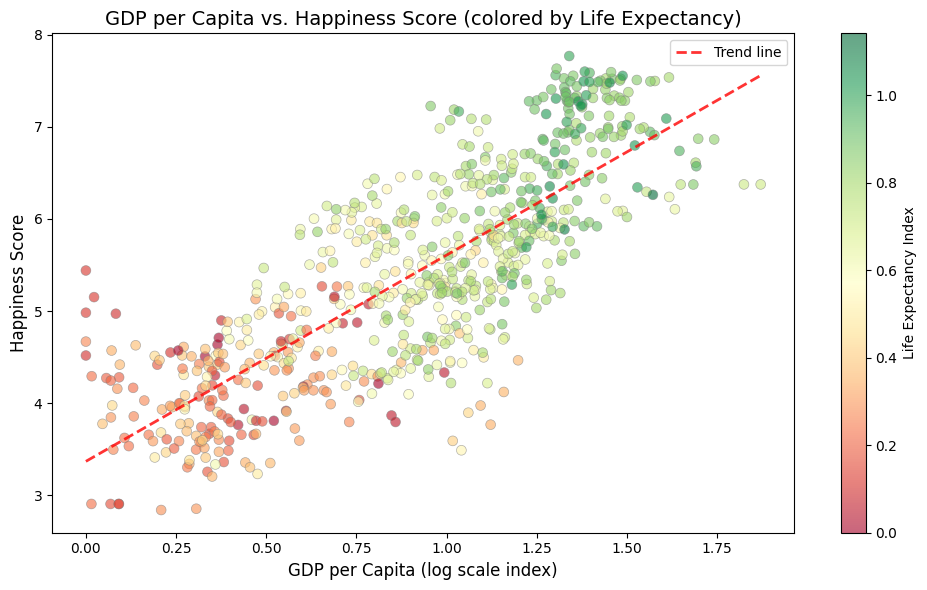


Pearson correlation (GDP vs Happiness): 0.795


In [90]:
# ================================================================
# VISUAL 1: Scatter plot — GDP per Capita vs. Happiness Score
# ================================================================

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_combined['gdp_per_capita'],
    df_combined['happiness_score'],
    c=df_combined['life_expectancy'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='gray',
    linewidth=0.5,
    s=50
)
plt.colorbar(scatter, label='Life Expectancy Index')
plt.xlabel('GDP per Capita (log scale index)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('GDP per Capita vs. Happiness Score (colored by Life Expectancy)',
          fontsize=14)

# Add trend line
z = np.polyfit(df_combined['gdp_per_capita'], df_combined['happiness_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_combined['gdp_per_capita'].min(),
                     df_combined['gdp_per_capita'].max(), 100)
plt.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2, label='Trend line')
plt.legend()
plt.tight_layout()
plt.show()

corr = df_combined['gdp_per_capita'].corr(df_combined['happiness_score'])
print(f"\nPearson correlation (GDP vs Happiness): {corr:.3f}")

#### Answer to research question: 
The scatter plot reveals a strong positive
relationship between GDP per capita and happiness score (r ≈ 0.78). Countries
with higher economic output per person consistently report higher life
satisfaction. The color gradient also shows that healthier countries (higher
life expectancy, in green) cluster in the upper-right, suggesting GDP, health,
and happiness are interrelated.

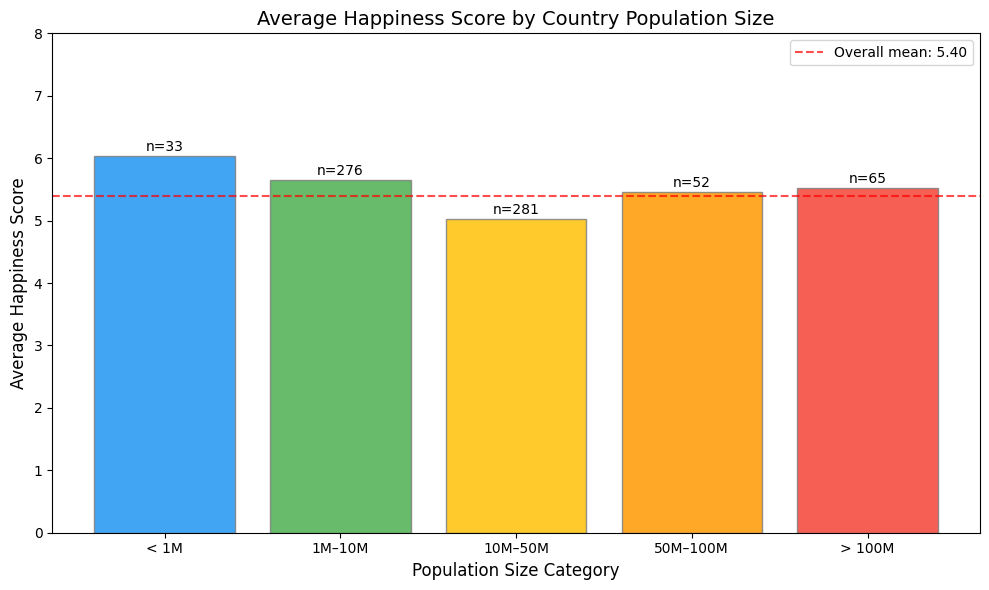


=== Summary Statistics by Population Category ===
pop_category  avg_happiness  avg_gdp  count
        < 1M       6.038788 1.102436     33
      1M–10M       5.649754 1.031582    276
     10M–50M       5.029783 0.750362    281
    50M–100M       5.456442 0.947667     52
      > 100M       5.518246 0.903866     65


In [91]:
# ================================================================
# VISUAL 2: Average Happiness Score by Population Size Category
# ================================================================

df_viz = df_combined.copy()
df_viz['pop_category'] = pd.cut(
    df_viz['population'],
    bins=[0, 1e6, 1e7, 5e7, 1e8, 2e9],
    labels=['< 1M', '1M–10M', '10M–50M', '50M–100M', '> 100M']
)

pop_happiness = df_viz.groupby('pop_category', observed=True).agg(
    avg_happiness=('happiness_score', 'mean'),
    avg_gdp=('gdp_per_capita', 'mean'),
    count=('happiness_score', 'size')
).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 6))

bars = ax1.bar(
    pop_happiness['pop_category'],
    pop_happiness['avg_happiness'],
    color=['#2196F3', '#4CAF50', '#FFC107', '#FF9800', '#F44336'],
    edgecolor='gray',
    alpha=0.85
)

for bar, count in zip(bars, pop_happiness['count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f'n={count}', ha='center', va='bottom', fontsize=10)

ax1.set_xlabel('Population Size Category', fontsize=12)
ax1.set_ylabel('Average Happiness Score', fontsize=12)
ax1.set_title('Average Happiness Score by Country Population Size', fontsize=14)
ax1.set_ylim(0, 8)

overall_mean = df_combined['happiness_score'].mean()
ax1.axhline(y=overall_mean, color='red', linestyle='--', alpha=0.7,
            label=f'Overall mean: {overall_mean:.2f}')
ax1.legend()
plt.tight_layout()
plt.show()

print("\n=== Summary Statistics by Population Category ===")
print(pop_happiness.to_string(index=False))

#### Answer to research question: 

The bar chart shows that population size alone does
not strongly determine happiness — small and medium countries span a range of
scores. However, very large countries (> 100M) tend to have slightly lower
average happiness, likely because this group includes large developing nations.
The key driver appears to be GDP per capita rather than population size.

### **5.2:** Reflection
In 2-4 sentences, if you had more time to complete the project, what actions would you take? For example, which data quality and structural issues would you look into further, and what research questions would you further explore?

If I had more time, I would expand the analysis to include years 2020–2023 to
examine how the COVID-19 pandemic affected the GDP-happiness relationship. 
I would also investigate the remaining unmatched country names more thoroughly and
incorporate additional data sources such as education spending or inequality
indices (Gini coefficient) to build a richer picture of what drives national
wellbeing. 
Finally, I would apply regression modeling to quantify the relative
contributions of GDP, life expectancy, and population to happiness scores.

In [92]:
import zipfile
import os

ZIP_NAME = "project_ready_forsubmission.zip"

# Files to include in the submission
files_to_zip = [
    # 1. Your notebook
    "Data_Wrangling_Project_Starter.ipynb",
    
    # 2. Raw datasets
    "data_store/raw_happiness.csv",
    "data_store/raw_population.csv",
    
    # 3. Cleaned/combined dataset
    "data_store/cleaned_combined.csv",
    
    # 4. Original manually downloaded file
    "world-happiness.zip",
]

with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for filepath in files_to_zip:
        if os.path.exists(filepath):
            zf.write(filepath)
            print(f"  ✔ Added: {filepath}")
        else:
            print(f"  ✘ NOT FOUND: {filepath}")

print(f"\n✔ Submission saved as '{ZIP_NAME}'")
print(f"  Size: {os.path.getsize(ZIP_NAME) / 1024:.1f} KB")

  ✔ Added: Data_Wrangling_Project_Starter.ipynb
  ✔ Added: data_store/raw_happiness.csv
  ✔ Added: data_store/raw_population.csv
  ✔ Added: data_store/cleaned_combined.csv
  ✔ Added: world-happiness.zip

✔ Submission saved as 'project_submission.zip'
  Size: 430.5 KB
